In [1]:
%matplotlib widget
from pathlib import Path
import matplotlib.pyplot as plt

import pandas as pd
import seaborn as sns

sns.set_theme("notebook", style="whitegrid")
Path.cwd()
data_dir = (Path.cwd().parent / ".data/").resolve()
assert data_dir.exists(), data_dir

## EX1
Consider the GDP information in global_economy. Plot the GDP per capita for each country
over time. Which country has the highest GDP per capita? How has this changed over time?

In [2]:
r_data_dir = data_dir / "r-data"
df = (
    pd.read_csv(r_data_dir / "global_economy.csv")
    .assign(Year= lambda df: pd.to_datetime(df.Year, format="%Y"))
    .set_index(["Year", "Country"])
    .assign(GDPPC=lambda df: df.GDP / df.Population)
    .drop_duplicates()
)
df

,,Code,GDP,Growth,CPI,Imports,Exports,Population,GDPPC
Year,Country,,,,,,,,
1960-01-01,Afghanistan,AFG,5.377778e+08,NaN,NaN,7.024793,4.132233,8996351.0,59.777327
1961-01-01,Afghanistan,AFG,5.488889e+08,NaN,NaN,8.097166,4.453443,9166764.0,59.878153
1962-01-01,Afghanistan,AFG,5.466667e+08,NaN,NaN,9.349593,4.878051,9345868.0,58.492874
1963-01-01,Afghanistan,AFG,7.511112e+08,NaN,NaN,16.863910,9.171601,9533954.0,78.782758
1964-01-01,Afghanistan,AFG,8.000000e+08,NaN,NaN,18.055555,8.888893,9731361.0,82.208444
...,...,...,...,...,...,...,...,...,...
2013-01-01,Zimbabwe,ZWE,1.909102e+10,1.989493,109.079488,36.668735,21.987759,15054506.0,1268.126633
2014-01-01,Zimbabwe,ZWE,1.949552e+10,2.376929,108.847215,33.741470,20.930146,15411675.0,1264.983826
2015-01-01,Zimbabwe,ZWE,1.996312e+10,1.779873,106.224541,37.588635,19.160176,15777451.0,1265.294413


In [3]:
si = lambda idx: df.index.get_level_values(idx)

# filter top 40 countries by avg GDPPC
mean_gdppc = (
    df
    .groupby(si("Country"))
    .GDPPC
    .mean()
    .nlargest(40)
)
top_idx = (
    mean_gdppc
    .index
)
df_top = df[si("Country").isin(top_idx)]

sit = lambda idx: df_top.index.get_level_values(idx)
sit("Country").unique(), mean_gdppc

(Index(['Andorra', 'Aruba', 'Australia', 'Austria', 'Belgium', 'Bermuda',
        'Brunei Darussalam', 'Canada', 'Cayman Islands', 'Channel Islands',
        'Denmark', 'Faroe Islands', 'Finland', 'France', 'Germany', 'Greenland',
        'Guam', 'High income', 'Iceland', 'Ireland', 'Isle of Man', 'Japan',
        'Kuwait', 'Liechtenstein', 'Luxembourg', 'Macao SAR, China', 'Monaco',
        'Netherlands', 'North America', 'Norway', 'Post-demographic dividend',
        'Qatar', 'San Marino', 'Singapore', 'Slovenia', 'Sweden', 'Switzerland',
        'United Arab Emirates', 'United Kingdom', 'United States'],
       dtype='object', name='Country'),
 Country
 Monaco                       86473.861561
 Liechtenstein                68091.597789
 San Marino                   59263.112646
 Cayman Islands               55867.705456
 Channel Islands              50912.446996
 Isle of Man                  49004.138776
 Luxembourg                   41360.534213
 Faroe Islands                39736

In [4]:
df_top

,,Code,GDP,Growth,CPI,Imports,Exports,Population,GDPPC
Year,Country,,,,,,,,
1960-01-01,Andorra,AND,NaN,NaN,NaN,NaN,NaN,13411.0,NaN
1961-01-01,Andorra,AND,NaN,NaN,NaN,NaN,NaN,14375.0,NaN
1962-01-01,Andorra,AND,NaN,NaN,NaN,NaN,NaN,15370.0,NaN
1963-01-01,Andorra,AND,NaN,NaN,NaN,NaN,NaN,16412.0,NaN
1964-01-01,Andorra,AND,NaN,NaN,NaN,NaN,NaN,17469.0,NaN
...,...,...,...,...,...,...,...,...,...
2013-01-01,United States,USA,1.669152e+13,1.677332,106.833849,16.586947,13.639312,316234505.0,52782.086509
2014-01-01,United States,USA,1.742761e+13,2.569194,108.566932,16.543618,13.620044,318622525.0,54696.726165
2015-01-01,United States,USA,1.812071e+13,2.861587,108.695722,15.390994,12.499044,321039839.0,56443.817242


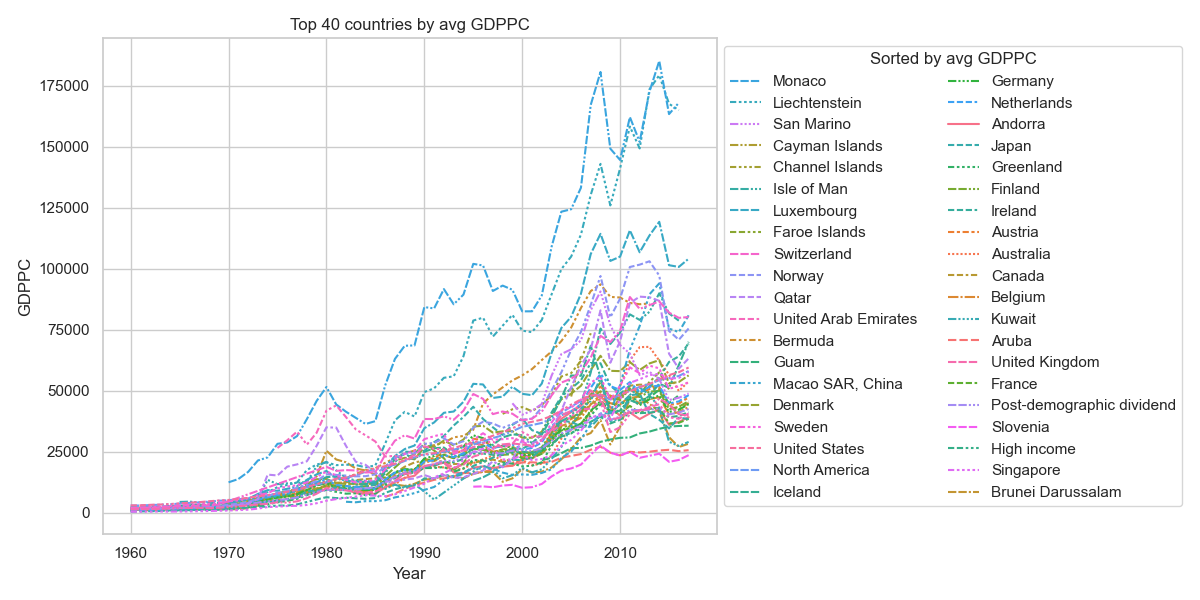

In [5]:
plt.figure(figsize=(12, 6))
ax = sns.lineplot(
    data=df_top, x=sit("Year"), y="GDPPC", hue=sit("Country"), style=sit("Country"),
)
handles, labels = ax.get_legend_handles_labels()
sorted_labels_handles = sorted(zip(labels, handles), key=lambda x: mean_gdppc[x[0]], reverse=True)
sorted_labels, sorted_handles = zip(*sorted_labels_handles)
plt.legend(sorted_handles, sorted_labels, loc="upper left", bbox_to_anchor=(1, 1), ncol=2, title="Sorted by avg GDPPC")
plt.title("Top 40 countries by avg GDPPC")
plt.tight_layout()
plt.show()

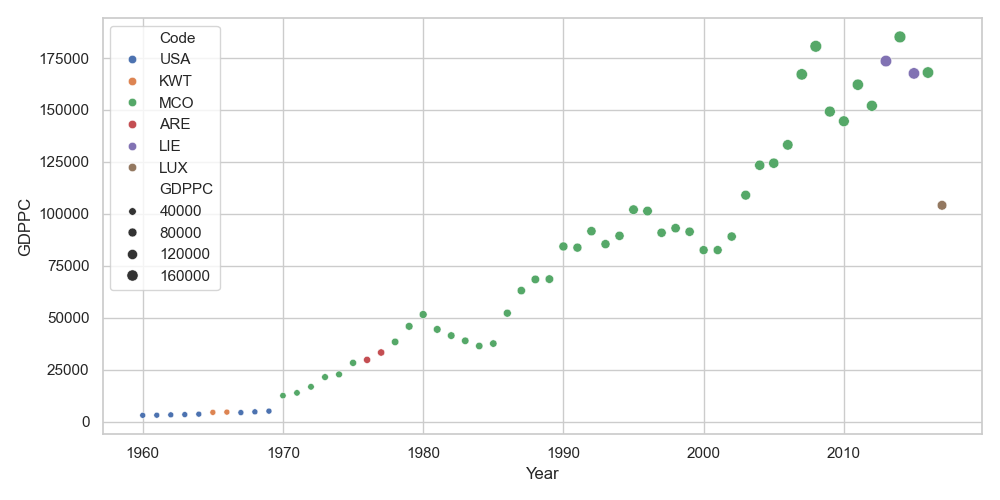

In [6]:
# Find the country with the highest GDP per capita for each year
highest_gdp_per_year = (
    df
    .groupby(level=0)
    .apply(lambda x: x.loc[x['GDPPC'].idxmax()])
    .reset_index()
)

plt.figure(figsize=(10, 5))
sns.scatterplot(highest_gdp_per_year, x="Year", y="GDPPC", hue="Code", size="GDPPC")
plt.tight_layout()
plt.show()

---

## EX2
For each of the following series, make a graph of the data. If transforming seems appropriate, do
so and describe the effect.
- United States GDP from `global_economy`
- Slaughter of Victorian “Bulls, bullocks and steers” in `aus_livestock`
- Victorian Electricity Demand from `vic_elec`.
- Gas production from `aus_production`

In [21]:
from darts import TimeSeries
from darts.dataprocessing.transformers.boxcox import BoxCox
from darts.utils.statistics import plot_acf
from darts.utils.statistics import seasonal_decompose

import numpy as np

optimal lambda: 0.2403637829093558


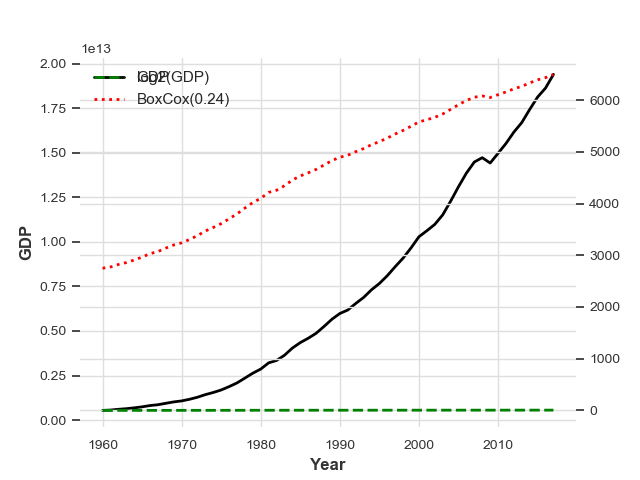

In [8]:
ts = (
    pd.read_csv(r_data_dir / "global_economy.csv")
    .assign(Year= lambda df: pd.to_datetime(df.Year, format="%Y"))
    .query("Code == 'USA'")
    .drop(columns=["Code", "Country"])
    .set_index("Year")
    .drop_duplicates()
    .pipe(lambda df: TimeSeries.from_dataframe(df, value_cols="GDP"))
)

ts_log = ts.map(np.log2)
ts_log = ts_log - ts_log[0]

boxcox = BoxCox().fit(ts)
opt_lmbda = boxcox._fitted_params[0][0]
print(
    f"optimal lambda: {opt_lmbda}"
)
ts_box = boxcox.transform(ts)

plt.figure()
ax = ts.plot()
ax.set_ylabel('GDP')
ax = ts_log.plot(ax=ax.twinx(), color="green", linestyle="--", label="log2(GDP)")
ax.set_ylabel('Transformed GDP')
ax = ts_box.plot(ax=ax, color="red", linestyle=":", label=f'BoxCox({opt_lmbda:.2f})')
plt.show()

`BoxCox` with $\lambda=0.24$ nearly fully linearizes the trend.

In [23]:
ts = (
    pd.read_csv(r_data_dir / "aus_livestock.csv", sep=";")
    .query("Animal == 'Bulls, bullocks and steers' and State == 'Victoria'")
    .drop(columns=["Animal", "State"])
    .assign(date=lambda df: pd.to_datetime(df[['year', 'month']].assign(day=1)))
    .drop(columns=["year", "month", "Month"])
    .set_index("date")
    .pipe(lambda df: TimeSeries.from_dataframe(df))
)

In [30]:
box_cox = BoxCox().fit(ts)
opt_lmbda = box_cox._fitted_params[0][0]
print(
    f"optimal lambda: {opt_lmbda}"
)
ts_tf = box_cox.transform(ts)

ts_ln_tf = BoxCox(lmbda=0).fit_transform(ts)

optimal lambda: -0.6483305823834765


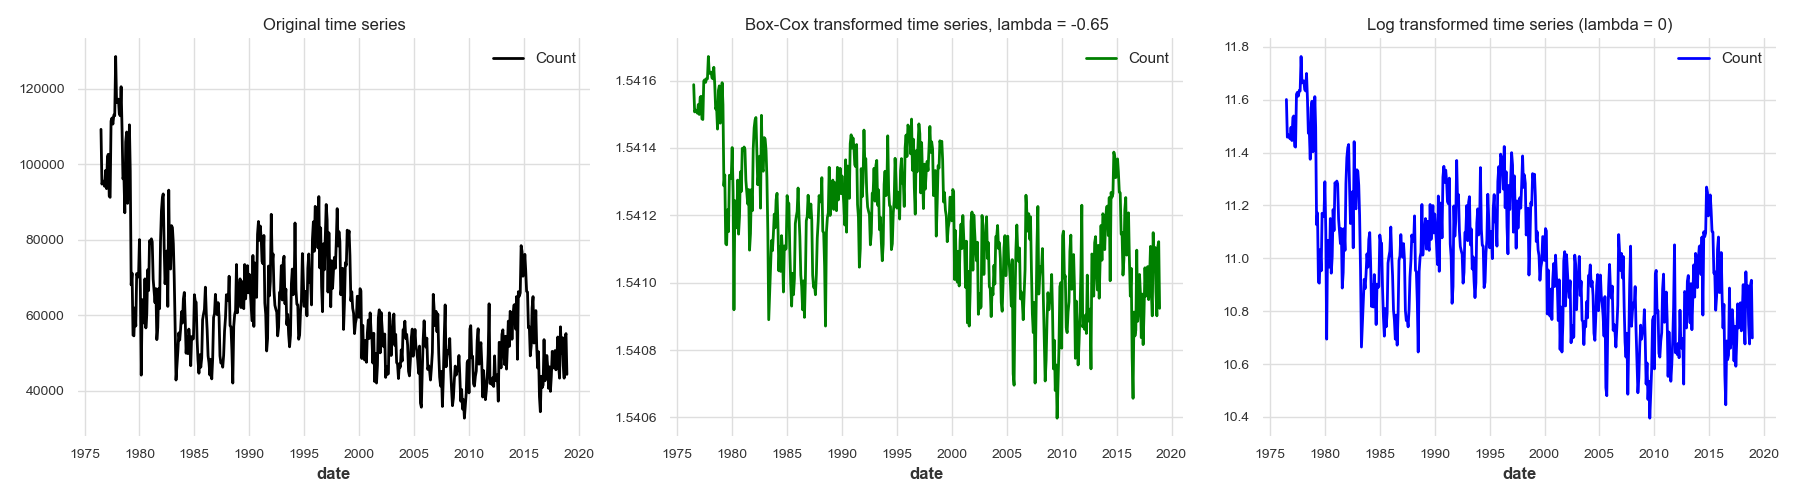

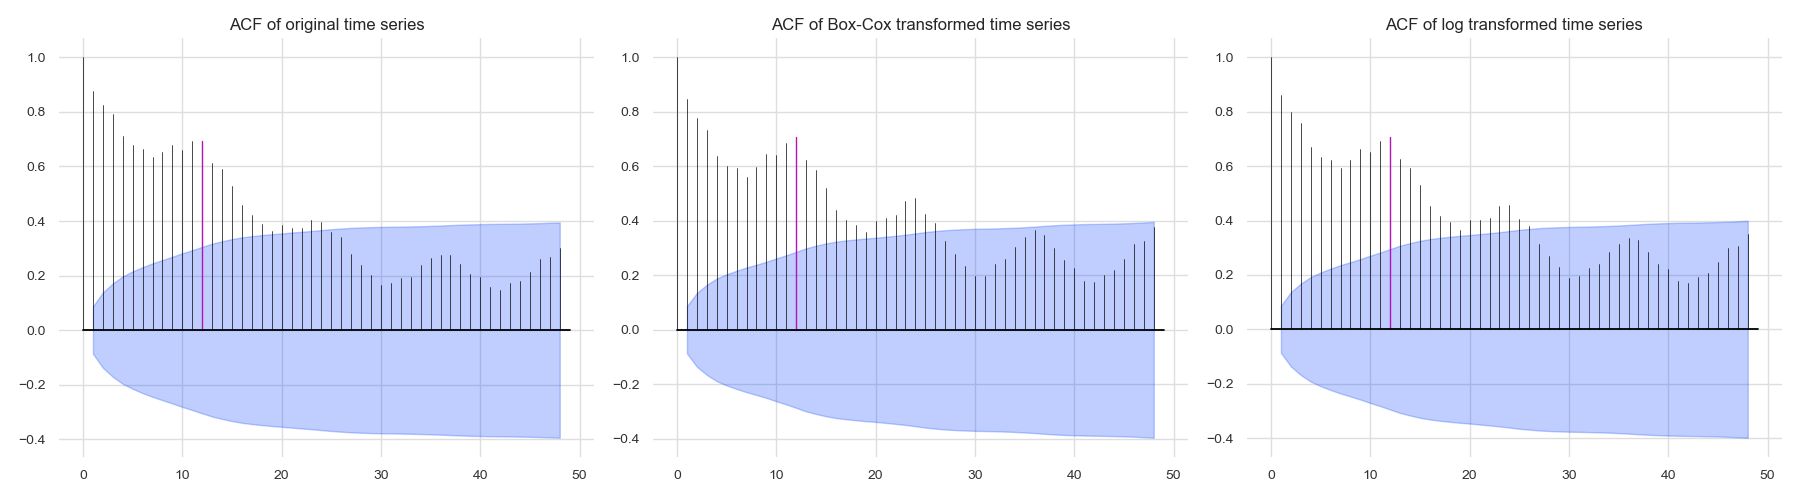

In [34]:
_, (ax0, ax1, ax2) = plt.subplots(1, 3, figsize=(18, 5))

ts.plot(ax=ax0)
ts_tf.plot(ax=ax1, color="green")
ts_ln_tf.plot(ax=ax2, color="blue")

ax0.set_title("Original time series")
ax1.set_title(f"Box-Cox transformed time series, lambda = {opt_lmbda:.2f}")
ax2.set_title("Log transformed time series (lambda = 0)")

plt.tight_layout()
plt.show()

# Plot the ACF of the original, Box-Cox transformed, and log-transformed time series
_, (ax0, ax1, ax2) = plt.subplots(1, 3, figsize=(18, 5))

plot_acf(ts, m=12, max_lag=48, axis=ax0)
ax0.set_title("ACF of original time series")

plot_acf(ts_tf, m=12, max_lag=48, axis=ax1)
ax1.set_title("ACF of Box-Cox transformed time series")

plot_acf(ts_ln_tf, m=12, max_lag=48, axis=ax2)
ax2.set_title("ACF of log transformed time series")

plt.tight_layout()
plt.show()

- `

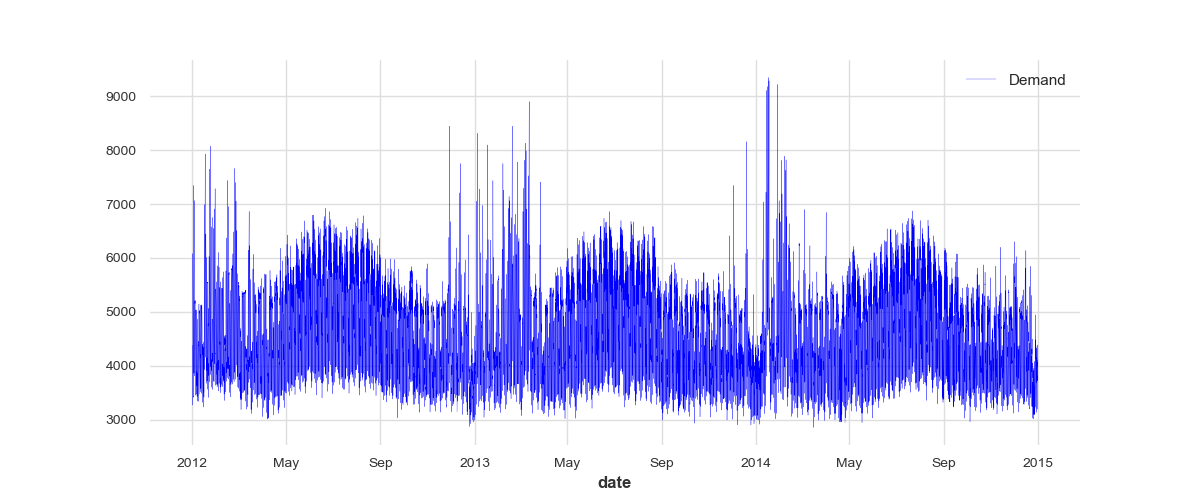

In [37]:
def conv_to_float(s):
    return s.str.replace(",", ".").astype(float)

ts = (
    pd.read_csv(r_data_dir / "vic_elec.csv", sep=";")
    .assign(
        date=lambda df: pd.to_datetime(df[["year", "month", "day", "hour", "minute"]]),
        Demand=lambda df: conv_to_float(df.Demand),
        Temperature=lambda df: conv_to_float(df.Temperature),
        Holiday=lambda df: df.Holiday.astype(bool)
    )
    .drop(columns=["year", "month", "day", "hour", "minute", "Time", "Date"])
    .drop_duplicates(subset=["date"])
    .set_index("date")
    .pipe(
        lambda df: TimeSeries.from_dataframe(
            df=df,
            value_cols=["Demand"],# "Temperature", "Holiday"],
            fill_missing_dates=True,
        )
    )
)

plt.figure(figsize=(12, 5))
ts.plot(lw=0.2, color="blue")
plt.show()

In [36]:
from ipywidgets import interact

@interact(lmbda=(-2.0, 2.0, 0.01))
def plot_boxcox(lmbda):
    transformer = BoxCox(lmbda=lmbda)
    transformed_ts = transformer.fit_transform(ts)
    plt.figure(figsize=(10, 6))
    transformed_ts.plot(label=f'Box-Cox Transformed (lambda={lmbda})', lw=0.3)
    plt.legend()
    plt.show()

plt.close()
interact(plot_boxcox, lmbda=(-2.0, 2.0, 0.01))

interactive(children=(FloatSlider(value=0.0, description='lmbda', max=2.0, min=-2.0, step=0.01), Output()), _d…

interactive(children=(FloatSlider(value=0.0, description='lmbda', max=2.0, min=-2.0, step=0.01), Output()), _d…

<function __main__.plot_boxcox(lmbda)>